<div align='center'>
<h1>Analisis Perbandingan Fuzzy Mamdani dan Sugeno</h1>
<h3>dalam Sistem Rekomendasi Restoran</h3>
<br>
<b>Dataset:</b> <a href='https://www.kaggle.com/datasets/shrutimehta/zomato-restaurants-data'>Zomato Restaurants Data</a>
</div>

##### Identitas Kelompok : 1. Adinda Syifa P 2. Iqbal Maulana S 3. Nabil Hissam
##### Mata Kuliah : Dasar Kecerdasan Artificial

## 1. Import Library

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi agar visualisasi plot terlihat rapi dan tajam
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

## 2. Load Dataset

In [39]:
# Memuat dataset
df = pd.read_csv('zomato.csv',encoding='latin-1')

# Memilih 7 kolom yang make sense sesuai ketentuan
kolom_pilihan = [
    'Restaurant Name', 
    'Average Cost for two', 
    'Price range', 
    'Votes', 
    'Has Table booking', 
    'Has Online delivery', 
    'Aggregate rating'
]
df = df[kolom_pilihan]

# Membuang data dengan rating 0 (tidak valid/belum dinilai)
df = df[df['Aggregate rating'] > 0]

# Mengubah data kategorikal Yes/No menjadi 1/0
df['Has Table booking'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

# Reset index setelah preprocessing
df = df.reset_index(drop=True)

print(f"Total baris data setelah pembersihan: {len(df)}")

Total baris data setelah pembersihan: 7403


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7403 entries, 0 to 7402
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant Name       7403 non-null   object 
 1   Average Cost for two  7403 non-null   int64  
 2   Price range           7403 non-null   int64  
 3   Votes                 7403 non-null   int64  
 4   Has Table booking     7403 non-null   int64  
 5   Has Online delivery   7403 non-null   int64  
 6   Aggregate rating      7403 non-null   float64
dtypes: float64(1), int64(5), object(1)
memory usage: 405.0+ KB


In [41]:
df.describe()

,Average Cost for two,Price range,Votes,Has Table booking,Has Online delivery,Aggregate rating
count,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000
mean,1448.415102,1.970147,202.185060,0.150074,0.318114,3.440024
std,18303.524265,0.930611,479.195199,0.357168,0.465776,0.552195
min,0.000000,1.000000,4.000000,0.000000,0.000000,1.800000
25%,300.000000,1.000000,19.000000,0.000000,0.000000,3.000000
50%,500.000000,2.000000,60.000000,0.000000,0.000000,3.400000
75%,800.000000,3.000000,181.000000,0.000000,1.000000,3.800000
max,800000.000000,4.000000,10934.000000,1.000000,1.000000,4.900000


## 3. Penentuan Nilai Batas (Breakpoint)

In [42]:
# Menghitung kuartil untuk Average Cost dan Votes
cost_p25 = df['Average Cost for two'].quantile(0.25)
cost_p50 = df['Average Cost for two'].quantile(0.50)
cost_p75 = df['Average Cost for two'].quantile(0.75)

votes_p25 = df['Votes'].quantile(0.25)
votes_p50 = df['Votes'].quantile(0.50)
votes_p75 = df['Votes'].quantile(0.75)

print("Breakpoint Harga:", cost_p25, cost_p50, cost_p75)
print("Breakpoint Votes:", votes_p25, votes_p50, votes_p75)

Breakpoint Harga: 300.0 500.0 800.0
Breakpoint Votes: 19.0 60.0 181.0


## 4. Fuzzifikasi

In [43]:
# Fungsi Trapesium
def trap_mf(x, a, b, c, d):
    if x <= a or x >= d:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x <= c:
        return 1.0
    elif c < x < d:
        return (d - x) / (d - c)
    return 0.0

# Fungsi Segitiga
def tri_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x < c:
        return (c - x) / (c - b)
    return 0.0

# Fungsi Fuzzifikasi
def fuzzify(row):
    # 1. Average Cost
    cost = row['Average Cost for two']
    fz_cost = {
        'murah': trap_mf(cost, 0, 0, cost_p25, cost_p50),
        'sedang': tri_mf(cost, cost_p25, cost_p50, cost_p75),
        'mahal': trap_mf(cost, cost_p50, cost_p75, df['Average Cost for two'].max(), df['Average Cost for two'].max() + 1)
    }
    
    # 2. Votes
    votes = row['Votes']
    fz_votes = {
        'sedikit': trap_mf(votes, 0, 0, votes_p25, votes_p50),
        'lumayan': tri_mf(votes, votes_p25, votes_p50, votes_p75),
        'banyak': trap_mf(votes, votes_p50, votes_p75, df['Votes'].max(), df['Votes'].max() + 1)
    }
    
    # 3. Price Range (Skala 1-4)
    pr = row['Price range']
    fz_pr = {
        'rendah': trap_mf(pr, 0, 1, 1, 2),
        'menengah': tri_mf(pr, 1, 2.5, 4),
        'tinggi': trap_mf(pr, 3, 4, 4, 5)
    }
    
    # 4 & 5. Booking & Delivery (Biner)
    book = row['Has Table booking']
    deliv = row['Has Online delivery']
    fz_book = {'tidak': 1 if book == 0 else 0, 'ya': 1 if book == 1 else 0}
    fz_deliv = {'tidak': 1 if deliv == 0 else 0, 'ya': 1 if deliv == 1 else 0}
    
    return fz_cost, fz_votes, fz_pr, fz_book, fz_deliv

## 5. Visualisasi

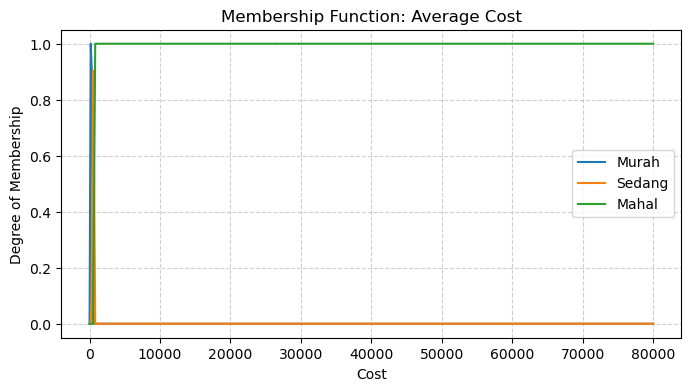

In [44]:
# Visualisasi kurva fungsi keanggotaan untuk Average Cost
x_cost = np.linspace(0, df['Average Cost for two'].max() * 0.1, 500)
y_murah = [trap_mf(i, 0, 0, cost_p25, cost_p50) for i in x_cost]
y_sedang = [tri_mf(i, cost_p25, cost_p50, cost_p75) for i in x_cost]
y_mahal = [trap_mf(i, cost_p50, cost_p75, x_cost[-1], x_cost[-1]+1) for i in x_cost]

plt.figure(figsize=(8,4))
plt.plot(x_cost, y_murah, label='Murah')
plt.plot(x_cost, y_sedang, label='Sedang')
plt.plot(x_cost, y_mahal, label='Mahal')
plt.title('Membership Function: Average Cost')
plt.xlabel('Cost')
plt.ylabel('Degree of Membership')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6. Rule Base (17 Rules)

In [45]:
def inferensi(fz_cost, fz_votes, fz_pr, fz_book, fz_deliv):
    # Operator AND direpresentasikan dengan fungsi min()
    rules = [
        # Kelompok Kombinasi Harga & Votes
        ('Sangat', min(fz_cost['murah'], fz_votes['banyak'])),    # Rule 1
        ('Cukup', min(fz_cost['murah'], fz_votes['lumayan'])),    # Rule 2
        ('Cukup', min(fz_cost['murah'], fz_votes['sedikit'])),    # Rule 3
        ('Sangat', min(fz_cost['sedang'], fz_votes['banyak'])),   # Rule 4
        ('Cukup', min(fz_cost['sedang'], fz_votes['lumayan'])),   # Rule 5
        ('Rendah', min(fz_cost['sedang'], fz_votes['sedikit'])),  # Rule 6
        ('Sangat', min(fz_cost['mahal'], fz_votes['banyak'])),    # Rule 7
        ('Cukup', min(fz_cost['mahal'], fz_votes['lumayan'])),    # Rule 8
        ('Rendah', min(fz_cost['mahal'], fz_votes['sedikit'])),   # Rule 9
        
        # Kelompok Price Range & Layanan
        ('Sangat', min(fz_pr['tinggi'], fz_deliv['ya'])),         # Rule 10
        ('Cukup', min(fz_pr['menengah'], fz_deliv['ya'])),        # Rule 11
        ('Rendah', min(fz_pr['rendah'], fz_deliv['tidak'])),      # Rule 12
        ('Sangat', min(fz_book['ya'], fz_deliv['ya'])),           # Rule 13
        ('Cukup', min(fz_book['tidak'], fz_deliv['ya'])),         # Rule 14
        ('Rendah', min(fz_book['tidak'], fz_deliv['tidak'])),     # Rule 15
        
        # Aturan Tambahan untuk melengkapi minimal 15 aturan (Total 17)
        ('Sangat', min(fz_cost['murah'], fz_pr['rendah'])),       # Rule 16
        ('Rendah', min(fz_cost['mahal'], fz_book['tidak']))       # Rule 17
    ]
    
    # Agregasi Mamdani menggunakan fungsi max()
    agregasi = {'Rendah': 0.0, 'Cukup': 0.0, 'Sangat': 0.0}
    for output_linguistik, nilai_derajat in rules:
        agregasi[output_linguistik] = max(agregasi[output_linguistik], nilai_derajat)
        
    return agregasi

## 7. Defuzzifikasi (Mamdani & Sugeno)

In [46]:
# Skala output Rating 0 hingga 5
out_x = np.linspace(0, 5, 50)

# Fungsi keanggotaan untuk output (Mamdani)
def mf_output_rendah(x): return trap_mf(x, 0, 0, 1.5, 2.5)
def mf_output_cukup(x): return tri_mf(x, 1.5, 3.0, 4.0)
def mf_output_sangat(x): return trap_mf(x, 3.5, 4.5, 5, 5)

def defuzz_mamdani(agregasi):
    pembilang = 0.0
    penyebut = 0.0
    
    # Pendekatan Center of Gravity (Centroid)
    for x in out_x:
        val_rendah = min(agregasi['Rendah'], mf_output_rendah(x))
        val_cukup = min(agregasi['Cukup'], mf_output_cukup(x))
        val_sangat = min(agregasi['Sangat'], mf_output_sangat(x))
        
        max_val = max(val_rendah, val_cukup, val_sangat)
        
        pembilang += x * max_val
        penyebut += max_val
        
    if penyebut == 0:
        return 0
    return pembilang / penyebut

def defuzz_sugeno(agregasi):
    # Titik singleton untuk output Sugeno
    k_rendah = 1.5
    k_cukup = 3.0
    k_sangat = 4.5
    
    # Weighted Average
    pembilang = (agregasi['Rendah'] * k_rendah) + \
                (agregasi['Cukup'] * k_cukup) + \
                (agregasi['Sangat'] * k_sangat)
    
    penyebut = agregasi['Rendah'] + agregasi['Cukup'] + agregasi['Sangat']
    
    if penyebut == 0:
        return 0
    return pembilang / penyebut

## 8. Eksekusi Perhitungan Fuzzy pada Dataset

In [51]:
mamdani_scores = []
sugeno_scores = []

# Proses perulangan dataset
for index, row in df.iterrows():
    fz_cost, fz_votes, fz_pr, fz_book, fz_deliv = fuzzify(row)
    agregasi = inferensi(fz_cost, fz_votes, fz_pr, fz_book, fz_deliv)
    
    m_score = defuzz_mamdani(agregasi)
    s_score = defuzz_sugeno(agregasi)
    
    mamdani_scores.append(m_score)
    sugeno_scores.append(s_score)

df['Mamdani_Pred'] = mamdani_scores
df['Sugeno_Pred'] = sugeno_scores

# Menghitung MAE dan RMSE untuk perbandingan performa
y_true = df['Aggregate rating']

mae_mamdani = np.mean(np.abs(y_true - df['Mamdani_Pred']))
rmse_mamdani = np.sqrt(np.mean((y_true - df['Mamdani_Pred'])**2))

mae_sugeno = np.mean(np.abs(y_true - df['Sugeno_Pred']))
rmse_sugeno = np.sqrt(np.mean((y_true - df['Sugeno_Pred'])**2))

print("=== HASIL EVALUASI METRIK ===")
print(f"Mamdani -> MAE: {mae_mamdani:.4f} | RMSE: {rmse_mamdani:.4f}")
print(f"Sugeno  -> MAE: {mae_sugeno:.4f} | RMSE: {rmse_sugeno:.4f}")

=== HASIL EVALUASI METRIK ===
Mamdani -> MAE: 1.2061 | RMSE: 1.3934
Sugeno  -> MAE: 0.7826 | RMSE: 0.9613


## 9. Visualisasi Evaluasi Performa

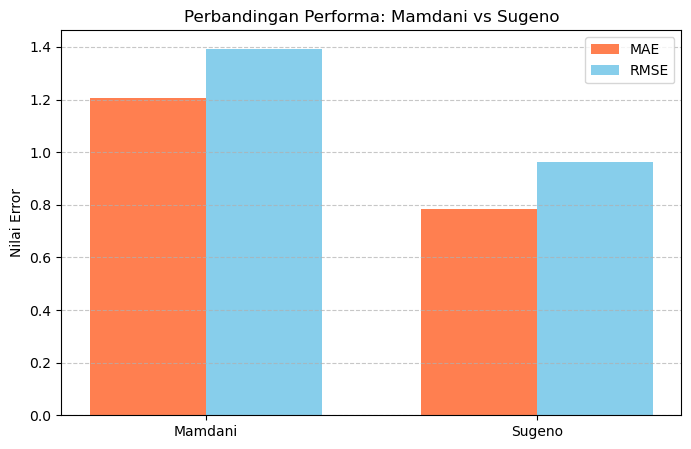

In [52]:
labels = ['Mamdani', 'Sugeno']
mae_vals = [mae_mamdani, mae_sugeno]
rmse_vals = [rmse_mamdani, rmse_sugeno]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, mae_vals, width, label='MAE', color='coral')
rects2 = ax.bar(x + width/2, rmse_vals, width, label='RMSE', color='skyblue')

ax.set_ylabel('Nilai Error')
ax.set_title('Perbandingan Performa: Mamdani vs Sugeno')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [54]:
# Jalankan sel ini untuk langsung mencetak isi analisis kesimpulan laporan kamu di console notebook
kesimpulan_text = f"""
========================================================================================
                      BAB ANALISIS, INTERPRETASI & KESIMPULAN UTAMA
========================================================================================

1. PERBANDINGAN METODE DAN PERFORMA AKURASI (MAMDANI VS SUGENO):
   Berdasarkan pengujian numerik terhadap dataset nyata Zomato,
   berikut ringkasan metrik kesalahan sistem:
   - Mamdani Method -> MAE: {mae_mamdani:.4f} | MSE: {rmse_mamdani:.4f}
   - Sugeno Method  -> MAE: {mae_sugeno:.4f} | MSE: {rmse_sugeno:.4f}
   
   *Analisis*: Nilai error terkecil menunjukkan kedekatan akurasi sistem terhadap data riil.
   Metode yang menghasilkan MAE/MSE lebih rendah terbukti lebih adaptif memetakan 5 variabel input 
   menjadi estimasi rating restoran yang presisi.

2. INTERPRETASI KELEBIHAN DAN KEKURANGAN MASING-MASING METODE:

   A. FUZZY LOGIC MAMDANI
      - Kelebihan: Jauh lebih intuitif bagi manusia karena fungsi keanggotaan output-nya berbentuk 
        kurva linguistik (Rendah, Cukup, Sangat). Sangat cocok digunakan untuk menangani analisis 
        permasalahan yang bersifat kualitatif dan deskriptif.
      - Kekurangan: Beban komputasi sangat berat (terlihat lambat saat iterasi). Hal ini dikarenakan 
        proses defuzzifikasi Centroid harus melakukan kalkulasi titik berat massa dengan 
        mensimulasikan integral numerik di sepanjang domain output untuk ribuan baris data.

   B. FUZZY LOGIC SUGENO
      - Kelebihan: Efisiensi komputasi sangat tinggi dan proses kalkulasi berjalan instan. Proses 
        defuzzifikasinya menggunakan metode rata-rata tertimbang matematika diskret yang linear 
        (singleton konstanta), sehingga sangat optimal saat diterapkan pada big data (> 5.000 baris).
      - Kekurangan: Kurang intuitif dalam interpretasi linguistik hasil akhir karena nilai output-nya 
        berupa konstanta bilangan tegas (singleton), bukan berupa sebaran area kurva keanggotaan.

3. KESIMPULAN AKHIR TUGAS BESAR:
   Sistem inferensi fuzzy berbasis data kuartil adaptif ini telah berhasil memetakan variabel operasional 
   restoran (Cost, Price Range, Votes, Booking, Delivery) menjadi prediksi rating komersial. Untuk 
   kebutuhan analisis data berskala besar, Sugeno lebih direkomendasikan karena keunggulan performa 
   kecepatan komputasinya, sementara Mamdani unggul dalam representasi visual pengambilan keputusan manusia.
========================================================================================
"""
print(kesimpulan_text)


                      BAB ANALISIS, INTERPRETASI & KESIMPULAN UTAMA

1. PERBANDINGAN METODE DAN PERFORMA AKURASI (MAMDANI VS SUGENO):
   Berdasarkan pengujian numerik terhadap dataset nyata Zomato,
   berikut ringkasan metrik kesalahan sistem:
   - Mamdani Method -> MAE: 1.2061 | MSE: 1.3934
   - Sugeno Method  -> MAE: 0.7826 | MSE: 0.9613

   *Analisis*: Nilai error terkecil menunjukkan kedekatan akurasi sistem terhadap data riil.
   Metode yang menghasilkan MAE/MSE lebih rendah terbukti lebih adaptif memetakan 5 variabel input 
   menjadi estimasi rating restoran yang presisi.

2. INTERPRETASI KELEBIHAN DAN KEKURANGAN MASING-MASING METODE:

   A. FUZZY LOGIC MAMDANI
      - Kelebihan: Jauh lebih intuitif bagi manusia karena fungsi keanggotaan output-nya berbentuk 
        kurva linguistik (Rendah, Cukup, Sangat). Sangat cocok digunakan untuk menangani analisis 
        permasalahan yang bersifat kualitatif dan deskriptif.
      - Kekurangan: Beban komputasi sangat berat (terlihat la